In [ ]:
from . import load_preprocess
def load_preprocessing():
    target = load_preprocess.target
    trains = load_preprocess.trains
    tests = load_preprocess.tests
    return trains, tests, target

all weather & wtg data merged complete!


In [ ]:
from . import scale_tensor
def split_and_to_tensor(trains, tests):
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_trains, X_valids, y_trains, y_valids, X_tests, X_alls = scale_tensor.train_valid_split(trains, tests)
    X_train, X_valid, y_train, y_valid, X_test, X_all = scale_tensor.to_tensor(X_trains, X_valids, y_trains, y_valids, X_tests, X_alls)
    X_train = X_train.to(device)
    X_valid = X_valid.to(device)
    y_train = y_train.to(device)
    y_valid = y_valid.to(device)
    X_test = X_test.to(device)
    X_all = X_all.to(device)
    return X_train, X_valid, y_train, y_valid, X_test, X_all

X_train tensor shape: torch.Size([275, 10, 24, 28])
X_valid tensor shape: torch.Size([90, 10, 24, 28])
y_train tensor shape: torch.Size([275, 24, 1])
y_valid tensor shape: torch.Size([90, 24, 1])
test_tensor shape: torch.Size([365, 10, 24, 28])
all_X_tensor shape: torch.Size([365, 10, 24, 28])


In [ ]:
from . import 양양model
import torch.nn as nn

Adjacency Matrix 
tensor([[1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [0., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.]])


In [ ]:
latitudes = 양양model.latitudes
longitudes = 양양model.longitudes

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = 양양model.FullModel(latitudes, longitudes, X_train)
model = model.to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0015, weight_decay=0.0015) #모델의 loss가 한값에 고정되어 나오면 lr을 조금씩 수정해주세요
early_stopping = 양양model.EarlyStopping(patience=30, verbose=True, delta=0.0001)

양양model.train_loop(model=model,
                   criterion=criterion,
                   optimizer=optimizer,
                   num_epochs=500,
                   early_stopping=early_stopping,
                   input_tensor=X_train,
                   valid_tensor=X_valid,
                   tg=y_train,
                   vt=y_valid)


Epoch 0, Train Loss: 0.127228, Validation Loss: 0.1631
Epoch 1, Train Loss: 0.117556, Validation Loss: 0.1624
Epoch 2, Train Loss: 0.117042, Validation Loss: 0.1621
Epoch 3, Train Loss: 0.116763, Validation Loss: 0.1619
Epoch 4, Train Loss: 0.116693, Validation Loss: 0.1618
Epoch 5, Train Loss: 0.116579, Validation Loss: 0.1616
Epoch 6, Train Loss: 0.116464, Validation Loss: 0.1615
Epoch 7, Train Loss: 0.116355, Validation Loss: 0.1613
EarlyStopping counter: 1/30
Epoch 8, Train Loss: 0.116243, Validation Loss: 0.1612
EarlyStopping counter: 2/30
Epoch 9, Train Loss: 0.116190, Validation Loss: 0.1612
EarlyStopping counter: 3/30
Epoch 10, Train Loss: 0.116195, Validation Loss: 0.1612
EarlyStopping counter: 4/30
Epoch 11, Train Loss: 0.116192, Validation Loss: 0.1612
Epoch 12, Train Loss: 0.116184, Validation Loss: 0.1612
EarlyStopping counter: 1/30
Epoch 13, Train Loss: 0.116173, Validation Loss: 0.1611
Epoch 14, Train Loss: 0.116161, Validation Loss: 0.1589
Epoch 15, Train Loss: 0.114875

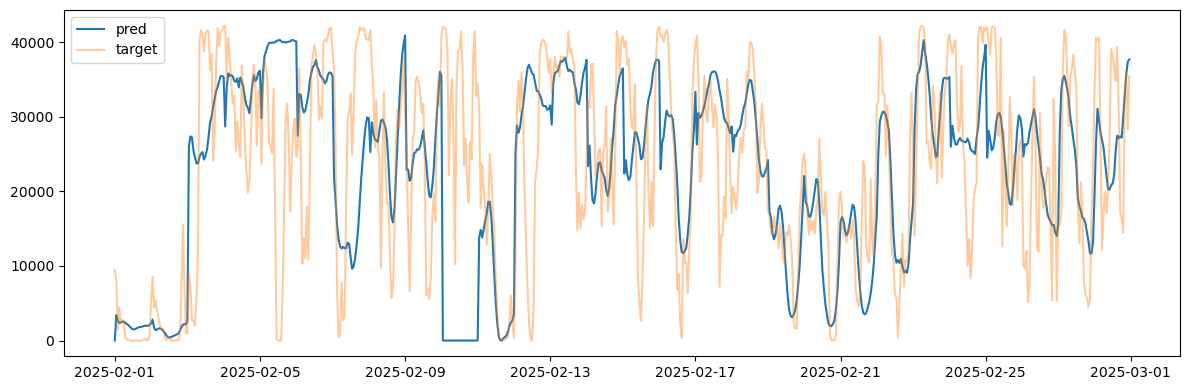

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

#Validation용 2023년 예측 및 시각화

model.eval()
with torch.no_grad():
    predictions  = model(X_valid)
    predictions_np = predictions.cpu().numpy() 

output = predictions_np
output = output.reshape(-1, 1)

output_inverse = scale_tensor.target_scaler.inverse_transform(output)
output_inverse = output_inverse.reshape(-1, 1)

pred = pd.DataFrame(output_inverse, columns = ["pred"])


target2023 = target.loc["2025-01-01":]
pred.index = trains["wtg_1"].loc["2025-01-01 01:00:00":].index
pred_loc = pred.loc["2025-02-01 00:00:00":"2025-02-28 23:00:00"]
target2023 = target2023.loc["2025-02-01 00:00:00":"2025-02-28 23:00:00"]

plt.figure(figsize = (12,4))
plt.plot(pred_loc.index, pred_loc, label = "pred")
plt.plot(target2023.index, target2023, label = "target", alpha = 0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pred_loc = pred_loc.fillna(0)
target2023 = target2023.fillna(0)
pred_loc.index = target2023.index

In [20]:
pred_loc.index = target2023.index

In [ ]:
#대회 전용 오차
#발전용량으로 정규화한 mae

#실제 센서데이터 사용시 NMAE 3~4 (사용 불가능. 2024년의 센서데이터가 없음)
#예측 센서데이터 사용시 NMAE 12~14(사용 가능)

def nmae(target, pred_target):
  mae = abs((target - pred_target))/42000
  nmae1 = mae.mean() * 100
  return nmae1

nmae1 = nmae(target2023["energy_kwh"], pred_loc["pred"])
print(nmae1)

20.025970715135674

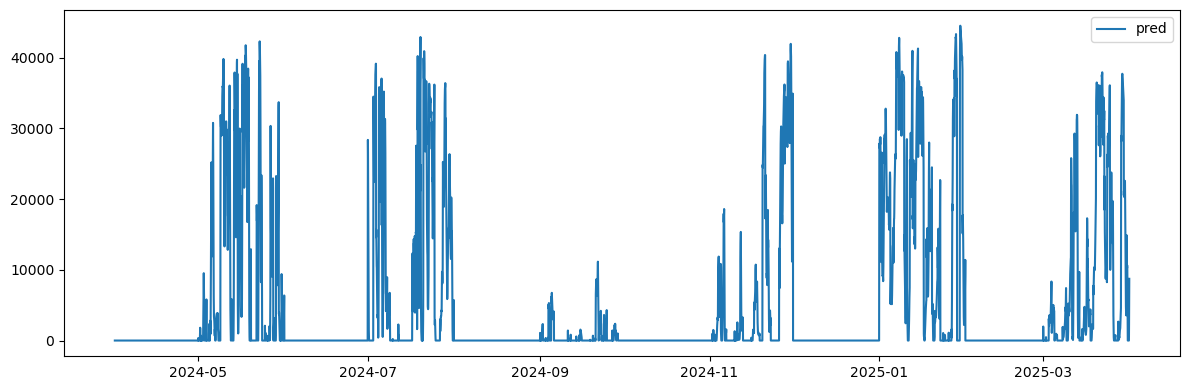

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

#Validation용 2023년 예측 및 시각화

model.eval()
with torch.no_grad():
    predictions  = model(X_test)
    predictions_np = predictions.cpu().numpy() 

output = predictions_np
output = output.reshape(-1, 1)

output_inverse = scale_tensor.target_scaler.inverse_transform(output)
output_inverse = output_inverse.reshape(-1, 1)

pred = pd.DataFrame(output_inverse, columns = ["pred"])


target2023 = target.loc["2025-01-01":]
pred.index = trains["wtg_1"].index

plt.figure(figsize = (12,4))
plt.plot(pred.index, pred, label = "pred")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pred.to_csv("./양양_모델/양양_예측/양양_pred.csv")